In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


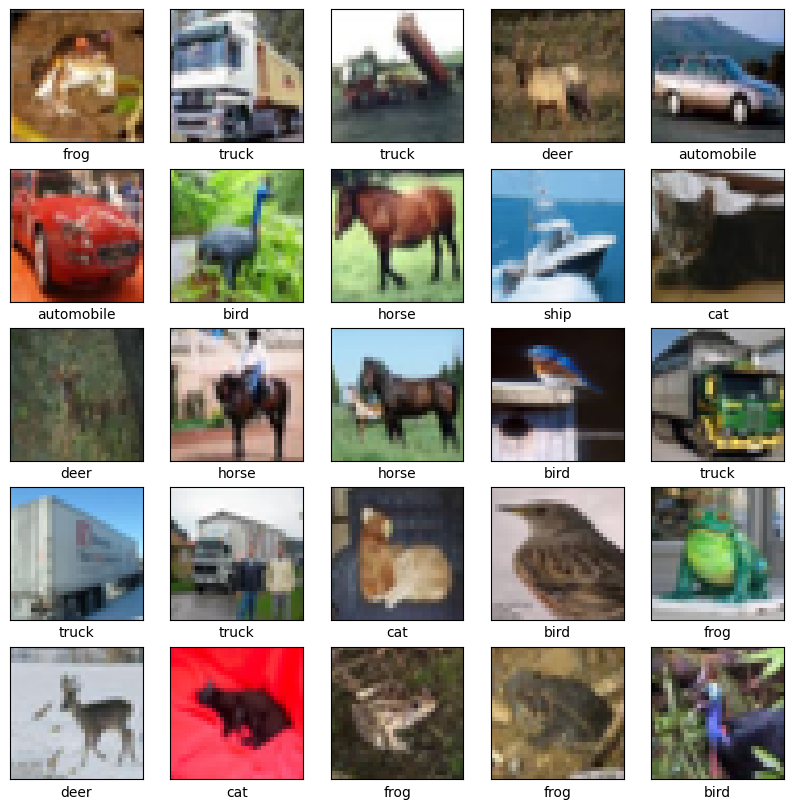

Class Distribution:
        Class  Count
0    airplane   5000
1  automobile   5000
2        bird   5000
3         cat   5000
4        deer   5000
5         dog   5000
6        frog   5000
7       horse   5000
8        ship   5000
9       truck   5000


In [ ]:
# Step 1: Load and Explore the Data (10 points)
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Determine training and testing data shapes.
print("Training data shape:", x_train_full.shape)  # (50000, 32, 32, 3)
print("Test data shape:", x_test.shape)  # (10000, 32, 32, 3)

# Define class names.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualize 25 samples.
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train_full[i])
    plt.xlabel(class_names[y_train_full[i][0]])
plt.show()

# Generate class distribution.
unique, counts = np.unique(y_train_full, return_counts=True)

# Create a DataFrame.
df_distribution = pd.DataFrame({
    'Class': class_names,
    'Count': counts
})

# Display the DataFrame.
print("Class Distribution:")
print(df_distribution)

In [ ]:
# Step 2: Split the Data for Training and Testing (10 points)
# Create validation set (20% of training data)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# Normalize data (scale pixels to [0, 1]).
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels.
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

c:\Users\rcc_0\AppData\Local\Programs\Python\Python312\Scripts\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.2246 - loss: 2.1844 - val_accuracy: 0.3461 - val_loss: 1.8183
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3237 - loss: 1.8610 - val_accuracy: 0.3837 - val_loss: 1.7477
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3513 - loss: 1.7893 - val_accuracy: 0.3901 - val_loss: 1.7147
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3698 - loss: 1.7541 - val_accuracy: 0.4128 - val_loss: 1.6440
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3877 - loss: 1.7049 - val_accuracy: 0.4197 - val_loss: 1.6207
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3940 - loss: 1.6797 - val_accuracy: 0.4262 - val_loss: 1.6023
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4086 - loss: 1.6434 - val_accuracy: 0.4447 - val_loss: 1.5773
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4078 - loss: 1.6414 - val_accu

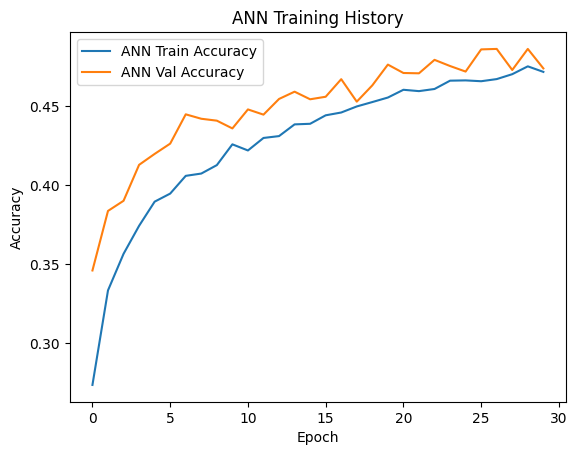

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ANN Test Accuracy: 0.4756
              precision    recall  f1-score   support

    airplane       0.65      0.41      0.50      1000
  automobile       0.58      0.52      0.55      1000
        bird       0.42      0.22      0.29      1000
         cat       0.32      0.36      0.34      1000
        deer       0.36      0.56      0.44      1000
         dog       0.44      0.35      0.39      1000
        frog       0.52      0.52      0.52      1000
       horse       0.57      0.51      0.54      1000
        ship       0.60      0.62      0.61      1000
       truck       0.44      0.68      0.53      1000

    accuracy                           0.48     10000
   macro avg       0.49      0.48      0.47     10000
weighted avg       0.49      0.48      0.47     10000



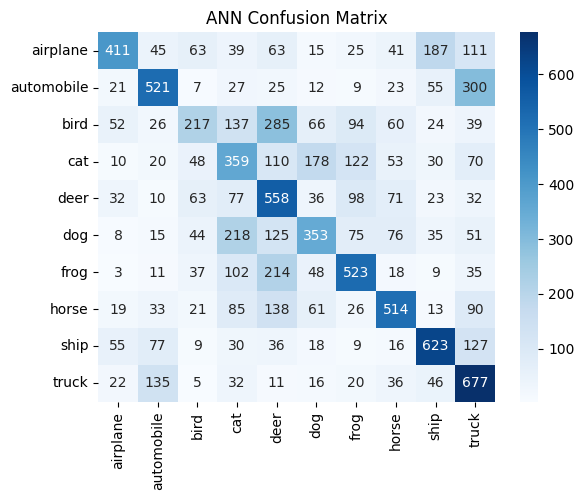

In [ ]:
# Step 3: Train the Model Using Simple Artificial Neural Network (ANN)
# Select and Build the Model (15 points)
ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Flatten to 1D (32*32*3 = 3072)
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])
ann_model.summary()

# Train the Model (5 points)
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ann = ann_model.fit(x_train, y_train, epochs=30, batch_size=128, validation_data=(x_val, y_val))

# Plot ANN training history.
plt.plot(history_ann.history['accuracy'], label='ANN Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='ANN Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ANN Training History')
plt.show()

# Make Predictions (5 points)
ann_predictions = ann_model.predict(x_test)
ann_pred_classes = np.argmax(ann_predictions, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Evaluate the Result (5 points)
ann_accuracy = accuracy_score(y_test_classes, ann_pred_classes)
print("ANN Test Accuracy:", ann_accuracy)
print(classification_report(y_test_classes, ann_pred_classes, target_names=class_names))

# Generate ANN confusion matrix.
cm_ann = confusion_matrix(y_test_classes, ann_pred_classes)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ANN Confusion Matrix')
plt.show()

In the training history chart, ANN Training and Validation accuracy began to converge after 30 epochs. ANN Testing accuracy garnered a f1-score of 0.48 approximately.  In the classification matrix, the 'bird' image recognition seemed the least reliable (f1-score: 0.29), and the 'ship' image recognition seemed the most reliable (f1-score: 0.61).  In the confusion matrix, the 'bird' image was interpreted more as a 'deer', which is surprising.  Some potentially understandable confusion between 'cat' and 'dog' images, as well as 'automobile' and 'truck' images, were noted.

c:\Users\rcc_0\AppData\Local\Programs\Python\Python312\Scripts\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.2283 - loss: 2.0374 - val_accuracy: 0.4439 - val_loss: 1.5317
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4059 - loss: 1.6145 - val_accuracy: 0.5004 - val_loss: 1.3662
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.4657 - loss: 1.4600 - val_accuracy: 0.5495 - val_loss: 1.2498
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.5126 - loss: 1.3590 - val_accuracy: 0.5840 - val_loss: 1.1611
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5471 - loss: 1.2720 - val_accuracy: 0.6053 - val_loss: 1.1074
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5758 - loss: 1.2078 - val_accuracy: 0.6165 - val_loss: 1.0709
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5946 - loss: 1.1496 - val_accuracy: 0.6306 - val_loss: 1.0351
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.6090 - loss: 1.1057 - 

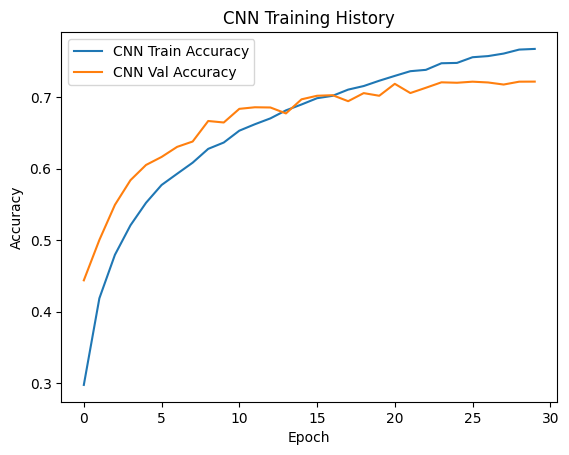

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
CNN Test Accuracy: 0.714
              precision    recall  f1-score   support

    airplane       0.72      0.76      0.74      1000
  automobile       0.87      0.84      0.86      1000
        bird       0.59      0.63      0.61      1000
         cat       0.48      0.58      0.53      1000
        deer       0.70      0.67      0.68      1000
         dog       0.69      0.52      0.59      1000
        frog       0.84      0.73      0.78      1000
       horse       0.81      0.70      0.75      1000
        ship       0.72      0.87      0.79      1000
       truck       0.80      0.82      0.81      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



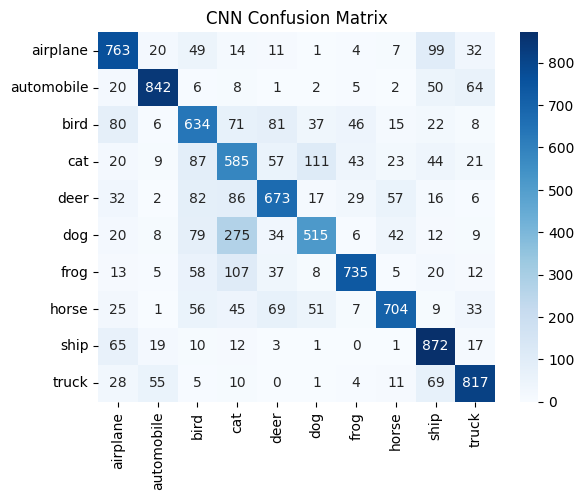

In [ ]:
# Step 4: Train a CNN and Check the Performance
# Select and Build the Model (20 points)
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
cnn_model.summary()

# Train the Model (5 points)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_cnn = cnn_model.fit(x_train, y_train, epochs=30, batch_size=128, validation_data=(x_val, y_val))

# Plot CNN training history.
plt.plot(history_cnn.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Training History')
plt.show()

# Make Predictions (10 points)
cnn_predictions = cnn_model.predict(x_test)
cnn_pred_classes = np.argmax(cnn_predictions, axis=1)

# Evaluate the Result (10 points)
cnn_accuracy = accuracy_score(y_test_classes, cnn_pred_classes)
print("CNN Test Accuracy:", cnn_accuracy)
print(classification_report(y_test_classes, cnn_pred_classes, target_names=class_names))

# Generate CNN confusion matrix.
cm_cnn = confusion_matrix(y_test_classes, cnn_pred_classes)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix')
plt.show()

In the training history chart, CNN Training accuracy eventually exceeded the Validation accuracy after 30 epochs, probably due to the larger sample size.  CNN Testing accuracy garnered a f1-score of 0.71 approximately.  In the classification matrix, the 'cat' image recognition seemed the least reliable (f1-score: 0.53), and the 'automobile' image recognition seemed the most reliable (f1-score: 0.86).  In the confusion matrix, the 'cat' image was sometimes confused with a 'dog', which is potentially understandable.

ANN Test Accuracy: 0.4756
CNN Test Accuracy: 0.7140
Improvement with CNN: 0.2384


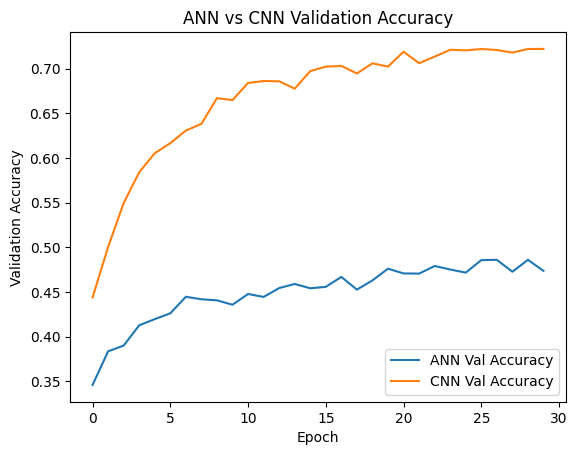

In [18]:
# Step 5: Compare the Two Models (5 points)
print(f"ANN Test Accuracy: {ann_accuracy:.4f}")
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")
imp_accuracy = cnn_accuracy - ann_accuracy
print(f"Improvement with CNN: {imp_accuracy:.4f}")

# Comparatively plot validation accuracies.
plt.plot(history_ann.history['val_accuracy'], label='ANN Val Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.show()

Discussion: CNN outperforms ANN because it uses convolutional layers to capture spatial features (e.g., edges, textures) in images, while ANN flattens the input and loses this information, leading to lower accuracy (typically ANN ~45-50%, CNN ~70-75% on CIFAR-10 with this setup).